Feature Engineering


In [ ]:
import pandas as pd
import numpy as np
hourly_df = pd.read_csv("smart_home_hours.csv",
parse_dates=['timestamp']
)
hourly_df.head()
hourly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87828 entries, 0 to 87827
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Appliance Type            87828 non-null  object        
 1   timestamp                 87828 non-null  datetime64[ns]
 2   Energy Consumption (kWh)  87828 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 2.0+ MB


In [ ]:
hourly_df = hourly_df.set_index('timestamp')
hourly_df['hour'] = hourly_df.index.hour
hourly_df['day'] = hourly_df.index.day
hourly_df['weekday'] = hourly_df.index.weekday
hourly_df['month'] = hourly_df.index.month
hourly_df['lag_1'] = hourly_df['Energy Consumption (kWh)'].shift(1)
hourly_df['lag_24'] = hourly_df['Energy Consumption (kWh)'].shift(24)
hourly_df['rolling_mean_24'] = (
hourly_df['Energy Consumption (kWh)']
.rolling(window=24)
.mean()
)
hourly_df = hourly_df.dropna()
appliances = hourly_df['Appliance Type'].unique()
print(f"Total appliances detected: {len(appliances)}")
print("Appliances:", appliances)

Total appliances detected: 10
Appliances: ['Air Conditioning' 'Computer' 'Dishwasher' 'Fridge' 'Heater' 'Lights'
 'Microwave' 'Oven' 'TV' 'Washing Machine']


In [ ]:
import os

# Ensure processed directory exists
os.makedirs("../data/processed", exist_ok=True)

appliances = hourly_df['Appliance Type'].unique()

for appliance in appliances:
    print(f"\nProcessing appliance: {appliance}")

    appliance_df = hourly_df[
        hourly_df['Appliance Type'] == appliance
    ].copy()

    # Features and target
    X = appliance_df.drop(
        ['Energy Consumption (kWh)', 'Appliance Type'],
        axis=1
    )
    y = appliance_df['Energy Consumption (kWh)']

    # Time-based split (80% train, 20% test)
    split_index = int(len(appliance_df) * 0.8)

    X_train = X.iloc[:split_index]
    X_test  = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test  = y.iloc[split_index:]

    # SAFE file name (important)
    safe_appliance = appliance.replace(" ", "_")

    # Save files
    X_train.to_csv(
        f"../data/processed/X_train_{safe_appliance}.csv",
        index=False
    )
    X_test.to_csv(
        f"../data/processed/X_test_{safe_appliance}.csv",
        index=False
    )
    y_train.to_csv(
        f"../data/processed/y_train_{safe_appliance}.csv",
        index=False
    )
    y_test.to_csv(
        f"../data/processed/y_test_{safe_appliance}.csv",
        index=False
    )

print("\n✅ Feature engineering completed for ALL appliances.")


Processing appliance: Air Conditioning

Processing appliance: Computer

Processing appliance: Dishwasher

Processing appliance: Fridge

Processing appliance: Heater

Processing appliance: Lights

Processing appliance: Microwave

Processing appliance: Oven

Processing appliance: TV

Processing appliance: Washing Machine

✅ Feature engineering completed for ALL appliances.


In [ ]:
import os

files = sorted(os.listdir("../data/processed"))
for f in files:
    print(f)


X_test_Air_Conditioning.csv
X_test_Computer.csv
X_test_Dishwasher.csv
X_test_Fridge.csv
X_test_Heater.csv
X_test_Lights.csv
X_test_Microwave.csv
X_test_Oven.csv
X_test_TV.csv
X_test_Washing_Machine.csv
X_train_Air_Conditioning.csv
X_train_Computer.csv
X_train_Dishwasher.csv
X_train_Fridge.csv
X_train_Heater.csv
X_train_Lights.csv
X_train_Microwave.csv
X_train_Oven.csv
X_train_TV.csv
X_train_Washing_Machine.csv
y_test_Air_Conditioning.csv
y_test_Computer.csv
y_test_Dishwasher.csv
y_test_Fridge.csv
y_test_Heater.csv
y_test_Lights.csv
y_test_Microwave.csv
y_test_Oven.csv
y_test_TV.csv
y_test_Washing_Machine.csv
y_train_Air_Conditioning.csv
y_train_Computer.csv
y_train_Dishwasher.csv
y_train_Fridge.csv
y_train_Heater.csv
y_train_Lights.csv
y_train_Microwave.csv
y_train_Oven.csv
y_train_TV.csv
y_train_Washing_Machine.csv


In [ ]:
hourly_df.head(35)

,Appliance Type,Energy Consumption (kWh),hour,day,weekday,month,lag_1,lag_24,rolling_mean_24
timestamp,,,,,,,,,
2023-01-02 00:00:00,Air Conditioning,3.51,0,2,0,1,4.76,4.42,4.473333
2023-01-02 01:00:00,Air Conditioning,4.41,1,2,0,1,3.51,7.61,4.340000
2023-01-02 02:00:00,Air Conditioning,2.11,2,2,0,1,4.41,14.80,3.811250
2023-01-02 03:00:00,Air Conditioning,3.47,3,2,0,1,2.11,4.19,3.781250
2023-01-02 04:00:00,Air Conditioning,9.11,4,2,0,1,3.47,10.68,3.715833
2023-01-02 05:00:00,Air Conditioning,0.00,5,2,0,1,9.11,6.94,3.426667
2023-01-02 06:00:00,Air Conditioning,4.19,6,2,0,1,0.00,0.00,3.601250
2023-01-02 07:00:00,Air Conditioning,6.29,7,2,0,1,4.19,0.00,3.863333
2023-01-02 08:00:00,Air Conditioning,0.00,8,2,0,1,6.29,4.95,3.657083


In [ ]:
for f in sorted(files):
    print(f)


X_test_Air_Conditioning.csv
X_test_Computer.csv
X_test_Dishwasher.csv
X_test_Fridge.csv
X_test_Heater.csv
X_test_Lights.csv
X_test_Microwave.csv
X_test_Oven.csv
X_test_TV.csv
X_test_Washing_Machine.csv
X_train_Air_Conditioning.csv
X_train_Computer.csv
X_train_Dishwasher.csv
X_train_Fridge.csv
X_train_Heater.csv
X_train_Lights.csv
X_train_Microwave.csv
X_train_Oven.csv
X_train_TV.csv
X_train_Washing_Machine.csv
y_test_Air_Conditioning.csv
y_test_Computer.csv
y_test_Dishwasher.csv
y_test_Fridge.csv
y_test_Heater.csv
y_test_Lights.csv
y_test_Microwave.csv
y_test_Oven.csv
y_test_TV.csv
y_test_Washing_Machine.csv
y_train_Air_Conditioning.csv
y_train_Computer.csv
y_train_Dishwasher.csv
y_train_Fridge.csv
y_train_Heater.csv
y_train_Lights.csv
y_train_Microwave.csv
y_train_Oven.csv
y_train_TV.csv
y_train_Washing_Machine.csv


Implement Linear Regression as baseline forecasting model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
data_path = "../data/processed/"
files = os.listdir(data_path)
appliances = sorted({
f.replace("X_train_", "").replace(".csv", "")
for f in files
if f.startswith("X_train_")
})
print(f"Detected appliances: {appliances}")

Detected appliances: ['Air_Conditioning', 'Computer', 'Dishwasher', 'Fridge', 'Heater', 'Lights', 'Microwave', 'Oven', 'TV', 'Washing_Machine']



Training Linear Regression for: Air_Conditioning
MAE  : 2.9819
RMSE : 3.7441


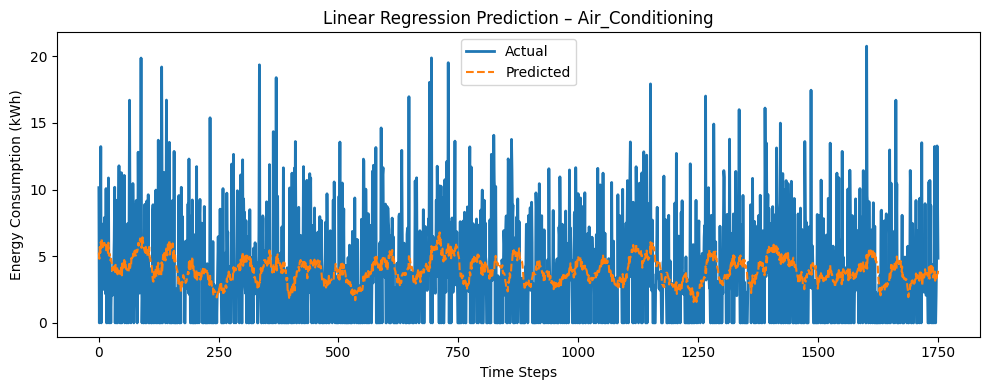


Training Linear Regression for: Computer
MAE  : 0.9922
RMSE : 1.2383


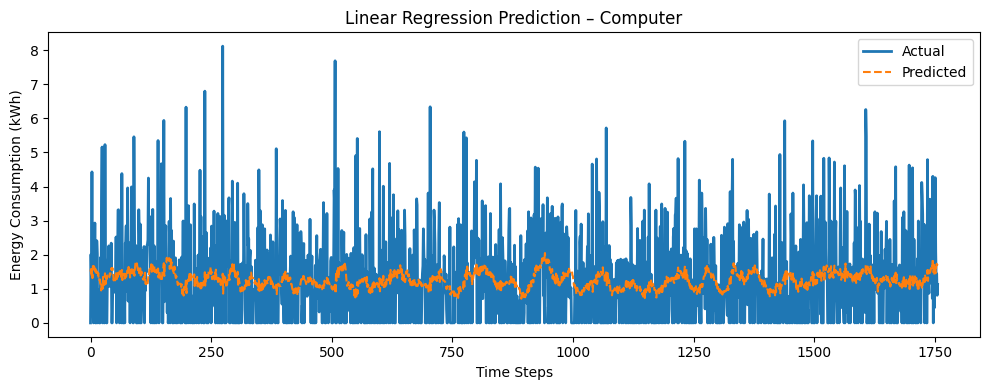


Training Linear Regression for: Dishwasher
MAE  : 1.0400
RMSE : 1.2991


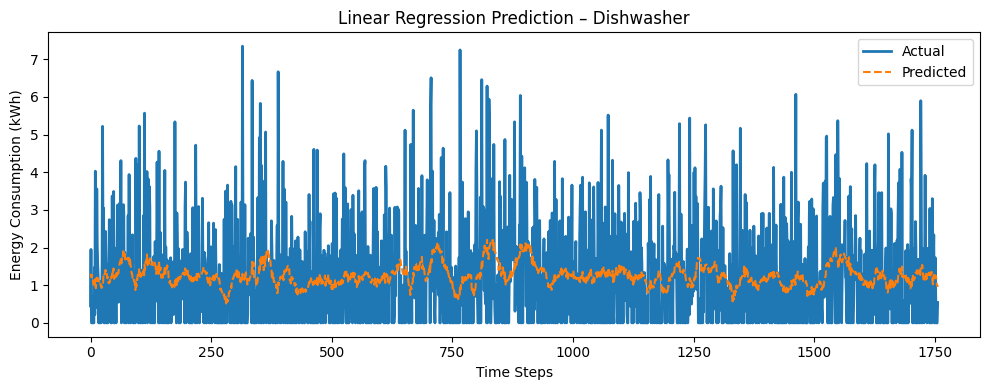


Training Linear Regression for: Fridge
MAE  : 0.2736
RMSE : 0.3389


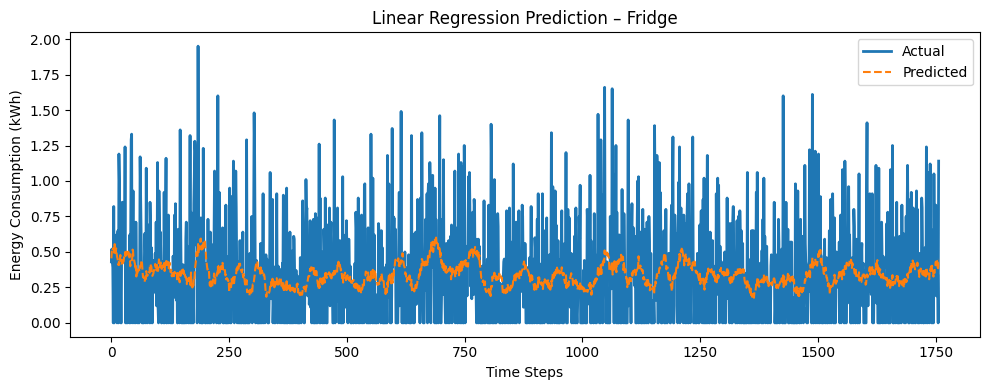


Training Linear Regression for: Heater
MAE  : 2.8667
RMSE : 3.6231


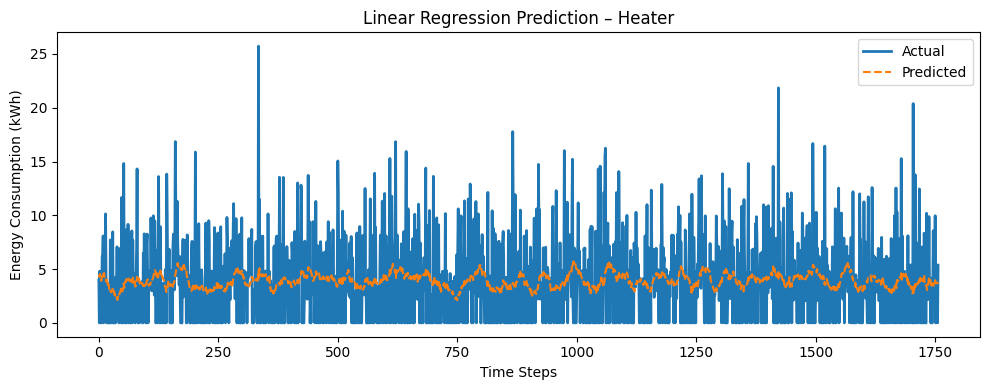


Training Linear Regression for: Lights
MAE  : 0.9820
RMSE : 1.2081


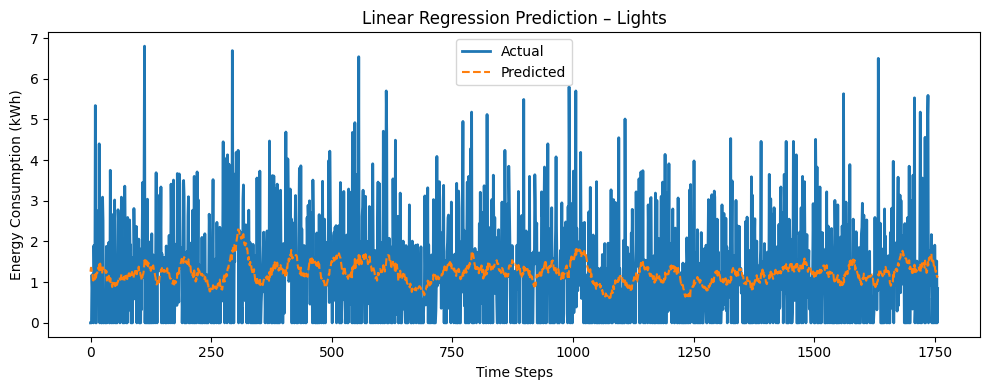


Training Linear Regression for: Microwave
MAE  : 1.0149
RMSE : 1.2794


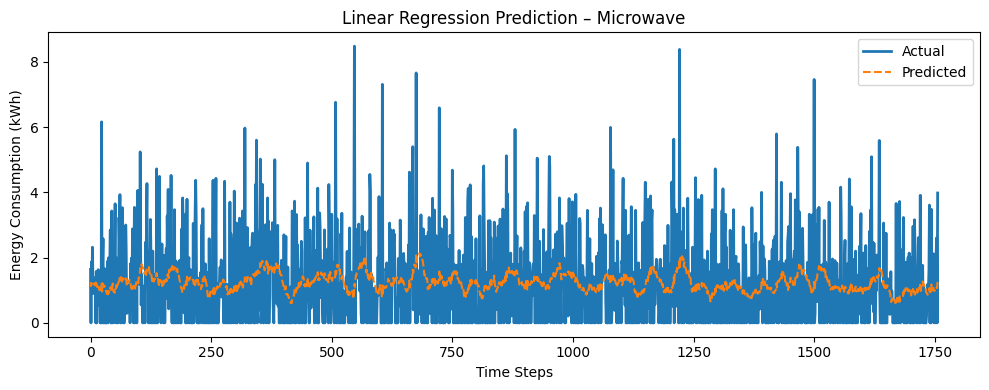


Training Linear Regression for: Oven
MAE  : 1.0286
RMSE : 1.2868


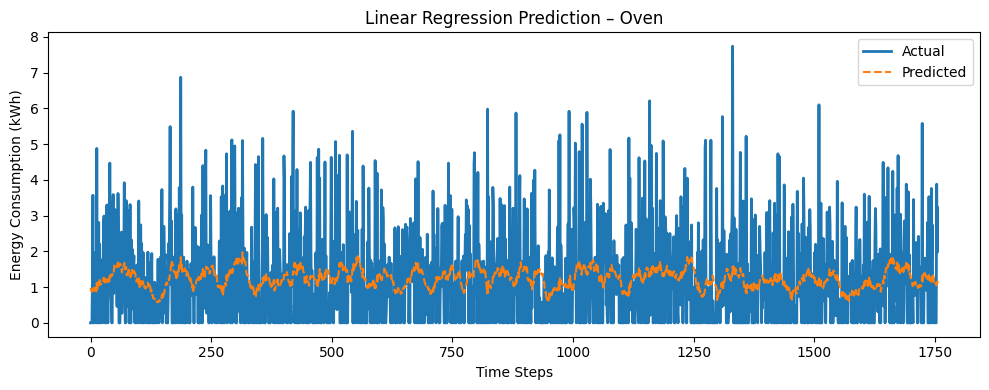


Training Linear Regression for: TV
MAE  : 0.9987
RMSE : 1.2408


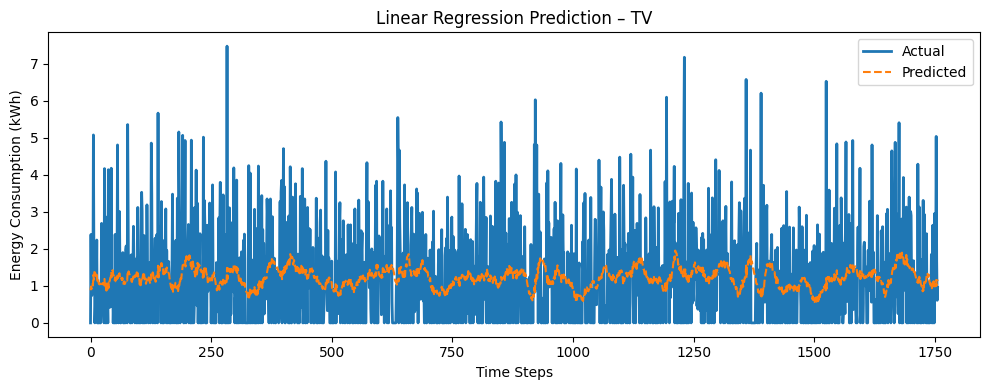


Training Linear Regression for: Washing_Machine
MAE  : 0.9814
RMSE : 1.2227


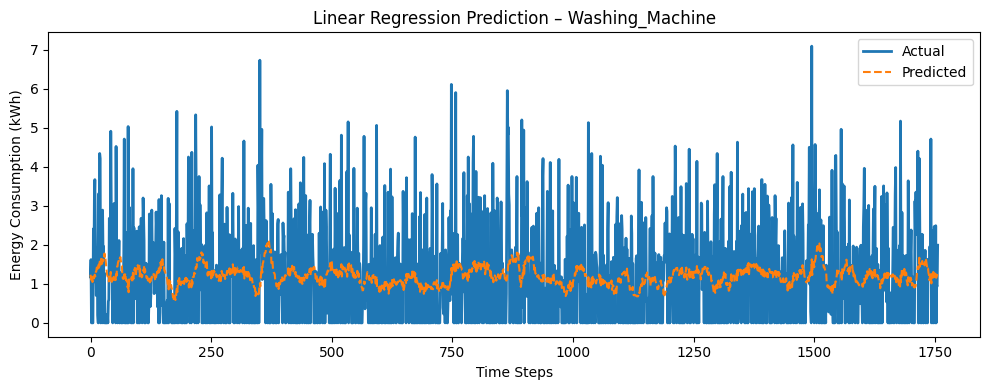

,Appliance,MAE,RMSE
0,Air_Conditioning,2.981943,3.744126
1,Computer,0.992192,1.238255
2,Dishwasher,1.040021,1.299050
3,Fridge,0.273553,0.338950
4,Heater,2.866735,3.623071
5,Lights,0.982039,1.208143
6,Microwave,1.014921,1.279435
7,Oven,1.028588,1.286755
8,TV,0.998717,1.240846
9,Washing_Machine,0.981406,1.222666


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

data_path = "../data/processed/"
os.makedirs("../models", exist_ok=True)

results = []

for appliance in appliances:
    print(f"\nTraining Linear Regression for: {appliance}")

    # Load data
    X_train = pd.read_csv(f"{data_path}X_train_{appliance}.csv")
    X_test  = pd.read_csv(f"{data_path}X_test_{appliance}.csv")
    y_train = pd.read_csv(
        f"{data_path}y_train_{appliance}.csv"
    ).values.ravel()
    y_test = pd.read_csv(
        f"{data_path}y_test_{appliance}.csv"
    ).values.ravel()

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Appliance": appliance,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(y_test, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", linestyle="--")
    plt.title(f"Linear Regression Prediction – {appliance}")
    plt.xlabel("Time Steps")
    plt.ylabel("Energy Consumption (kWh)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Save model
    joblib.dump(
        model,
        f"../models/linear_regression_{appliance}.pkl"
    )

# Results summary
results_df = pd.DataFrame(results)
results_df
